# Exercício 1 — Construção da Árvore

In [43]:
Valores = [53, 30, 72, 14, 39, 61, 84, 9, 23, 34, 49, 79]


# Mostre o dicionário completo da árvore
# Informe qual é a raiz
# Explique por que cada valor foi para esquerda ou direita.



arvore = {}

def construir_arvore(valores):

    for valor in valores:

        if len(arvore) == 0:
            arvore[valor] = {
                "esquerda": None,
                "direita": None
            }
            raiz = valor

        else:
            atual = raiz

            while True:
                if valor < atual:
                    if arvore[atual]["esquerda"] is None:
                        arvore[atual]["esquerda"] = valor
                        arvore[valor] = {
                            "esquerda": None,
                            "direita": None
                        }
                        break
                    else:
                        atual = arvore[atual]["esquerda"]

                else:
                    if arvore[atual]["direita"] is None:

                        arvore[atual]["direita"] = valor

                        arvore[valor] = {
                            "esquerda": None,
                            "direita": None
                        }

                        break

                    else:
                        atual = arvore[atual]["direita"]

    return raiz

raiz = construir_arvore(Valores)
print("Árvore Completa:", arvore)
print("Raiz da Árvore:", raiz)

Árvore Completa: {53: {'esquerda': 30, 'direita': 72}, 30: {'esquerda': 14, 'direita': 39}, 72: {'esquerda': 61, 'direita': 84}, 14: {'esquerda': 9, 'direita': 23}, 39: {'esquerda': 34, 'direita': 49}, 61: {'esquerda': None, 'direita': None}, 84: {'esquerda': 79, 'direita': None}, 9: {'esquerda': None, 'direita': None}, 23: {'esquerda': None, 'direita': None}, 34: {'esquerda': None, 'direita': None}, 49: {'esquerda': None, 'direita': None}, 79: {'esquerda': None, 'direita': None}}
Raiz da Árvore: 53


In [44]:
import matplotlib.pyplot as plt

def calcular_posicoes(arvore, no, x=0, y=0, dx=1.0, posicoes=None):

    if posicoes is None:
        posicoes = {}

    if no is not None:

        posicoes[no] = (x, y)

        calcular_posicoes(
            arvore,
            arvore[no]["esquerda"],
            x - dx,
            y - 1,
            dx / 2,
            posicoes
        )

        calcular_posicoes(
            arvore,
            arvore[no]["direita"],
            x + dx,
            y - 1,
            dx / 2,
            posicoes
        )

    return posicoes


def desenhar_arvore(
    arvore,
    raiz,
    titulo="Árvore Binária",
    destacado=None,
    caminho=None
):

    if raiz is None or len(arvore) == 0:
        print("Árvore vazia.")
        return

    if caminho is None:
        caminho = []

    posicoes = calcular_posicoes(arvore, raiz)

    plt.figure(figsize=(12, 7))

    for no, filhos in arvore.items():

        x1, y1 = posicoes[no]

        for lado in ["esquerda", "direita"]:

            filho = filhos[lado]

            if filho is not None:

                x2, y2 = posicoes[filho]

                plt.plot(
                    [x1, x2],
                    [y1, y2],
                    color="black",
                    linewidth=2,
                    zorder=1
                )

    if len(caminho) > 1:

        for i in range(len(caminho) - 1):

            no1 = caminho[i]
            no2 = caminho[i + 1]

            x1, y1 = posicoes[no1]
            x2, y2 = posicoes[no2]

            plt.plot(
                [x1, x2],
                [y1, y2],
                color="red",
                linewidth=4,
                zorder=2
            )

    for no, (x, y) in posicoes.items():

        if no == destacado:
            facecolor = "lightcoral"

        elif no in caminho:
            facecolor = "lightgreen"

        else:
            facecolor = "white"

        plt.text(
            x,
            y,
            str(no),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            bbox=dict(
                boxstyle="circle",
                facecolor=facecolor,
                edgecolor="black",
                linewidth=2
            ),
            zorder=3
        )

    plt.title(titulo, fontsize=14)
    plt.axis("off")
    plt.show()

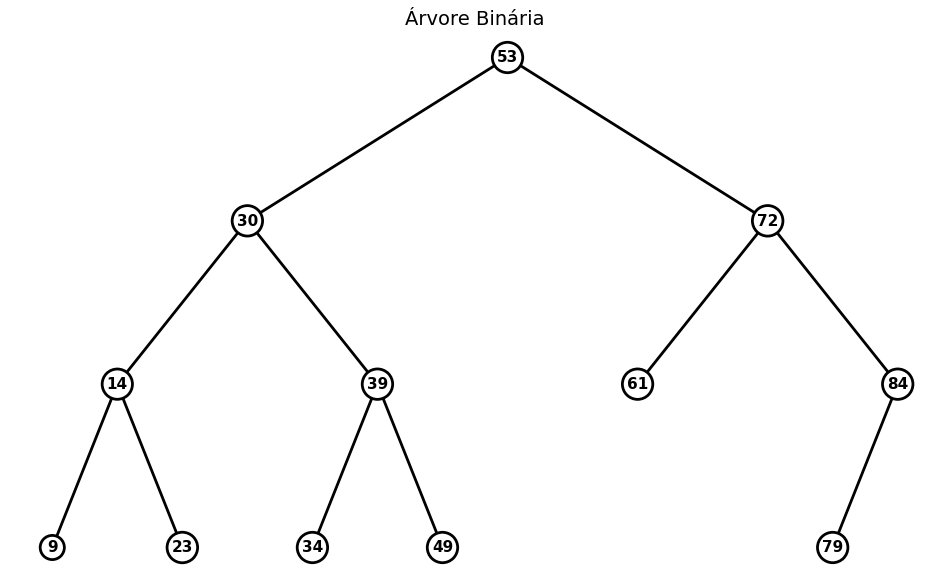

In [45]:
desenhar_arvore(arvore, raiz)

# Exercício 2 — Inserção de Novos Valores


Nó atual: 53
18 < 53
Mover para esquerda

Nó atual: 30
18 < 30
Mover para esquerda

Nó atual: 14
18 >= 14
Mover para direita

Nó atual: 23
18 < 23
Mover para esquerda
Valor 18 inserido à esquerda de 23.

Caminho percorrido na inserção:
[53, 30, 14, 23]


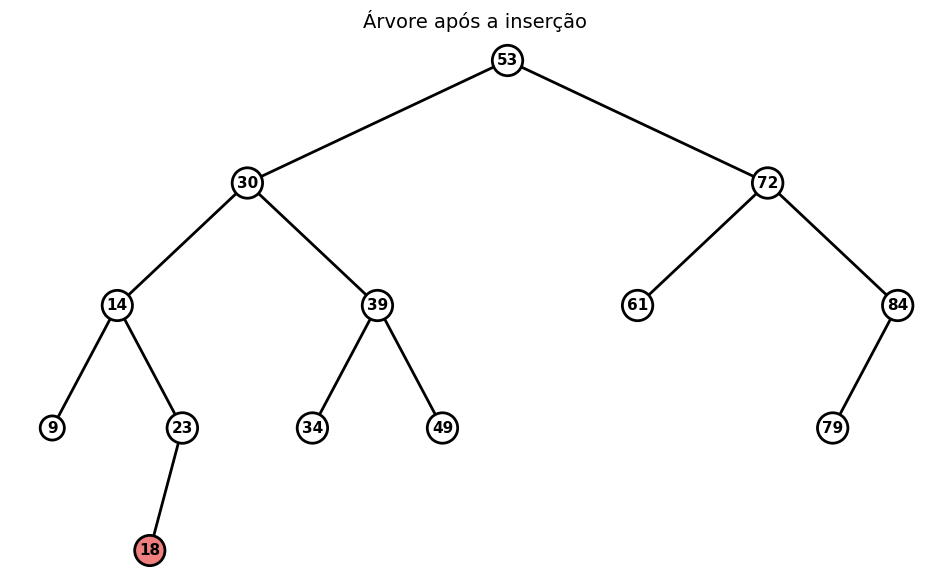

In [46]:
#valor_inserir = 65
#valor_inserir = 90
valor_inserir = 18

if len(arvore) == 0:

    arvore[valor_inserir] = {
        "esquerda": None,
        "direita": None
    }

    raiz = valor_inserir

    print(f"O valor {valor_inserir} foi inserido como raiz da árvore.")

else:

    atual = raiz

    caminho_insercao = []

    while True:

        caminho_insercao.append(atual)

        print(f"\nNó atual: {atual}")

        if valor_inserir < atual:

            print(f"{valor_inserir} < {atual}")
            print("Mover para esquerda")

            if arvore[atual]["esquerda"] is None:

                arvore[atual]["esquerda"] = valor_inserir

                arvore[valor_inserir] = {
                    "esquerda": None,
                    "direita": None
                }

                print(f"Valor {valor_inserir} inserido à esquerda de {atual}.")
                break

            else:
                atual = arvore[atual]["esquerda"]

        else:

            print(f"{valor_inserir} >= {atual}")
            print("Mover para direita")

            if arvore[atual]["direita"] is None:

                arvore[atual]["direita"] = valor_inserir

                arvore[valor_inserir] = {
                    "esquerda": None,
                    "direita": None
                }

                print(f"Valor {valor_inserir} inserido à direita de {atual}.")
                break

            else:
                atual = arvore[atual]["direita"]

print("\nCaminho percorrido na inserção:")
print(caminho_insercao)

desenhar_arvore(
    arvore,
    raiz,
    "Árvore após a inserção",
    destacado=valor_inserir
)

# Exercício 3 — Busca de Elementos

Valor encontrado
Caminho percorrido: [53, 72, 84]

 Foram visitados : 3 nós.


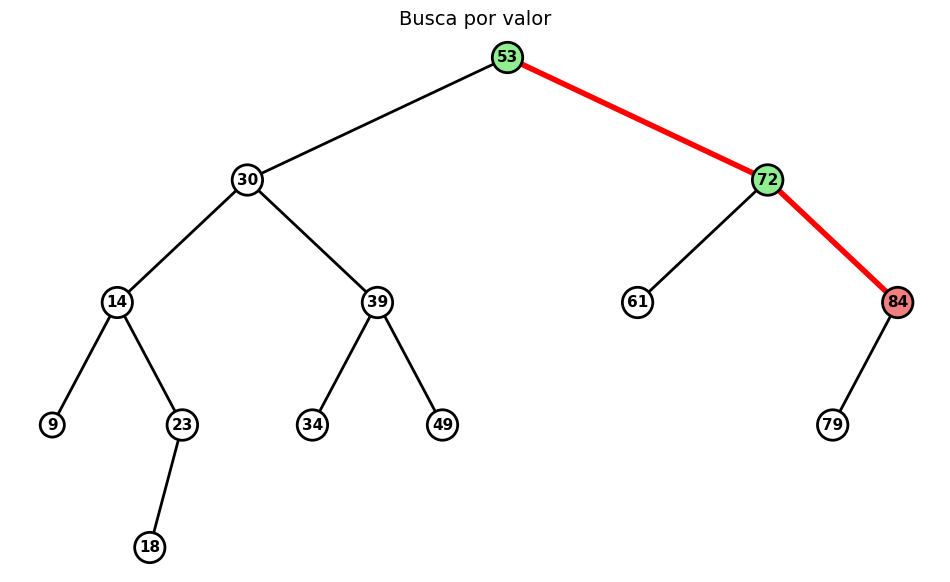

In [47]:
valor_procurado = 84

atual = raiz

caminho = []

encontrou = False

while atual is not None:

    caminho.append(atual)

    if valor_procurado == atual:

        encontrou = True

        break

    elif valor_procurado < atual:

        atual = arvore[atual]["esquerda"]

    else:

        atual = arvore[atual]["direita"]

if encontrou:

    print("Valor encontrado")

else:

    print("Valor não encontrado")

print("Caminho percorrido:", caminho)

print("\n Foram visitados :", len(caminho) , "nós.")
desenhar_arvore(
    arvore,
    raiz,
    "Busca por valor",
    destacado=valor_procurado,
    caminho=caminho
)

# Exercício 4 — Travessia Pré-Ordem

In [48]:
pre_ordem=[]

pilha = [raiz]

while len(pilha) > 0:

    atual = pilha.pop()
    pre_ordem.append(atual)

    if arvore[atual]["direita"] is not None:
        pilha.append(arvore[atual]['direita'])
    if arvore[atual]["esquerda"] is not None:
        pilha.append(arvore[atual]['esquerda'])

print("Travessia Pré-Ordem:", pre_ordem)

Travessia Pré-Ordem: [53, 30, 14, 9, 23, 18, 39, 34, 49, 72, 61, 84, 79]


# Exercício 5 — Travessia Em Ordem

In [49]:
em_ordem = []

pilha = []

atual = raiz

while atual is not None or len(pilha) > 0:
    while atual is not None:
        pilha.append(atual)

        atual = arvore[atual]["esquerda"]

    atual = pilha.pop()
    em_ordem.append(atual)

    atual = arvore[atual]["direita"]

print("Travessia em ordem:", em_ordem)

Travessia em ordem: [9, 14, 18, 23, 30, 34, 39, 49, 53, 61, 72, 79, 84]


# Exercício 6 — Travessia Pós-Ordem

In [50]:
pos_ordem = []

pilha1 = [raiz]

pilha2 = []

while len(pilha1) > 0:

    atual = pilha1.pop()

    pilha2.append(atual)

    if arvore[atual]["esquerda"] is not None:

        pilha1.append(arvore[atual]["esquerda"])

    if arvore[atual]["direita"] is not None:

        pilha1.append(arvore[atual]["direita"])

while len(pilha2) > 0:

    pos_ordem.append(pilha2.pop())

print("Travessia pós-ordem:")
print(pos_ordem)

Travessia pós-ordem:
[9, 18, 23, 14, 34, 49, 39, 30, 61, 79, 84, 72, 53]


# Exercício 7 — Altura da Árvore

In [51]:
def altura(arvore, no):
    if no is None:
        return 0

    esquerda = altura(arvore, arvore[no]["esquerda"])
    direita = altura(arvore, arvore[no]["direita"])

    return 1 + max(esquerda, direita)

print("Altura:", altura(arvore, raiz))
print("Número total de nós:", len(arvore))
print("Caminho que gera a altura:", caminho)

Altura: 5
Número total de nós: 13
Caminho que gera a altura: [53, 72, 84]


# Exercício 8 — Contagem de Nós

In [52]:
def altura_com_contagem(arvore, no, contagem):
    if no is None:
        return 0

    contagem[0] += 1

    esquerda = altura_com_contagem(arvore, arvore[no]["esquerda"], contagem)
    direita = altura_com_contagem(arvore, arvore[no]["direita"], contagem)

    return 1 + max(esquerda, direita)
contagem = [0]
altura_resultado = altura_com_contagem(arvore, raiz, contagem)
print("Número de nós visitados para calcular a altura:", contagem[0])

Número de nós visitados para calcular a altura: 13


# Exercício 9 — Menor e Maior Valor

In [53]:
def encontrar_menor(arvore, no):
    atual = no

    while arvore[atual]["esquerda"] is not None:
        atual = arvore[atual]["esquerda"]

    return atual

def encontrar_maior(arvore, no):
    atual = no

    while arvore[atual]["direita"] is not None:
        atual = arvore[atual]["direita"]

    return atual
menor_valor = encontrar_menor(arvore, raiz)
maior_valor = encontrar_maior(arvore, raiz)
print("Menor valor na árvore:", menor_valor)
print("Maior valor na árvore:", maior_valor)

Menor valor na árvore: 9
Maior valor na árvore: 84


# Exercício 10 — Remoção de Nó Folha

In [54]:
valor_remover = 9
def remover_no(arvore, no, valor_remover):
    encontrado = [False]
    nova_raiz = _remover_no(arvore, no, valor_remover, encontrado)
    if not encontrado[0]:
        print(f"Valor {valor_remover} não encontrado na árvore.")
    return nova_raiz

def _remover_no(arvore, no, valor_remover, encontrado):
    if no is None:
        return None

    if valor_remover < no:
        arvore[no]["esquerda"] = _remover_no(arvore, arvore[no]["esquerda"], valor_remover, encontrado)

    elif valor_remover > no:
        arvore[no]["direita"] = _remover_no(arvore, arvore[no]["direita"], valor_remover, encontrado)

    else:
        encontrado[0] = True
        if arvore[no]["esquerda"] is None and arvore[no]["direita"] is None:
            del arvore[no]
            return None

        elif arvore[no]["esquerda"] is None:
            temp = arvore[no]["direita"]
            del arvore[no]
            return temp

        elif arvore[no]["direita"] is None:
            temp = arvore[no]["esquerda"]
            del arvore[no]
            return temp

        else:
            sucessor = encontrar_menor(arvore, arvore[no]["direita"])
            arvore[no]["direita"] = _remover_no(arvore, arvore[no]["direita"], sucessor, [False])
            arvore[sucessor] = {
                "esquerda": arvore[no]["esquerda"],
                "direita": arvore[no]["direita"],
            }
            del arvore[no]
            return sucessor

    return no


Valor 9 removido da árvore.


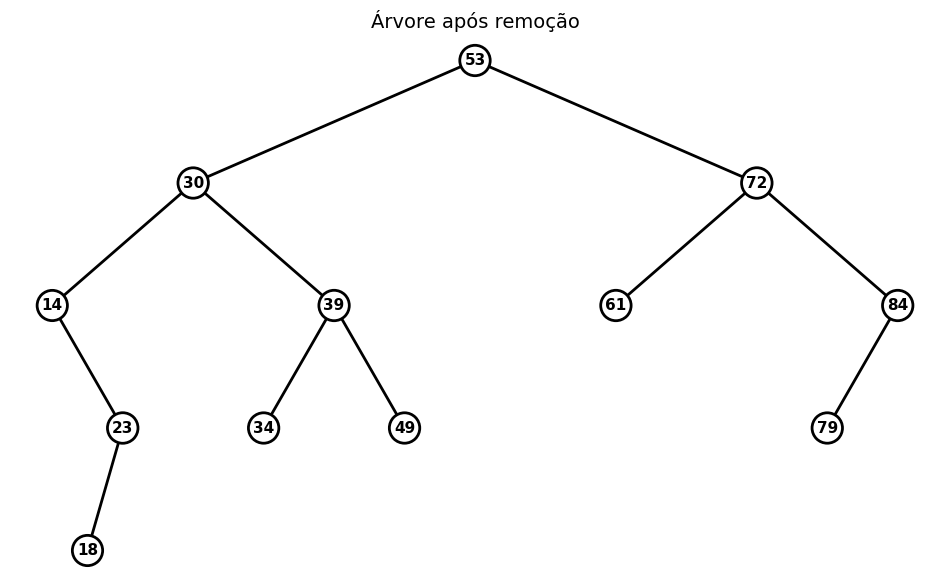

In [55]:
valor_remover = 9

raiz = remover_no(arvore, raiz, valor_remover)
print(f"Valor {valor_remover} removido da árvore.")
desenhar_arvore(
    arvore,
    raiz,
    "Árvore após remoção",
    destacado=valor_remover
)


# Exercício 11 — Remoção de Nó com Um Filho

Valor 14 removido da árvore.


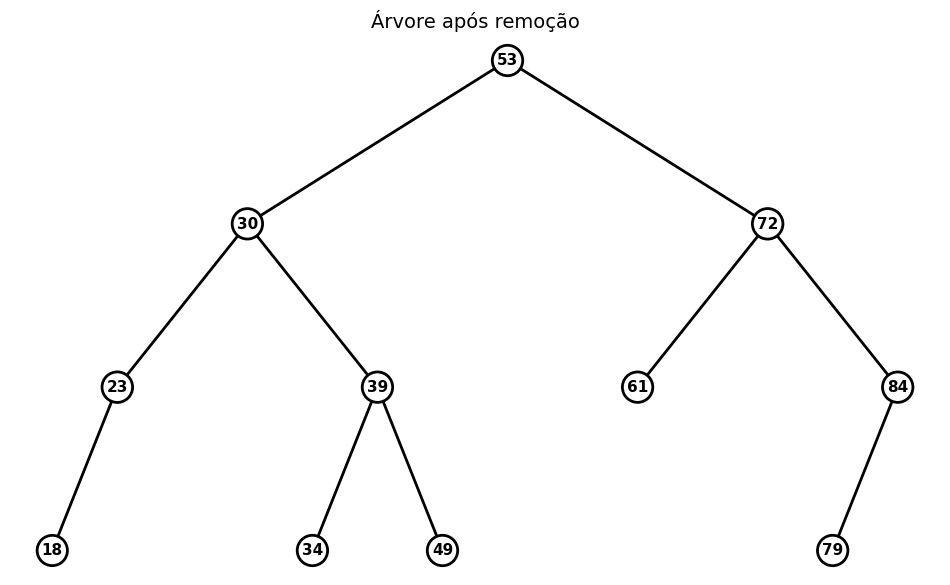

In [56]:
valor_remover = 14
raiz = remover_no(arvore, raiz, valor_remover)
print(f"Valor {valor_remover} removido da árvore.")
desenhar_arvore(
    arvore,
    raiz,
    "Árvore após remoção",
    destacado=valor_remover
)

# Exercício 12 — Remoção de Nó com Dois Filhos

Valor 39 removido da árvore.


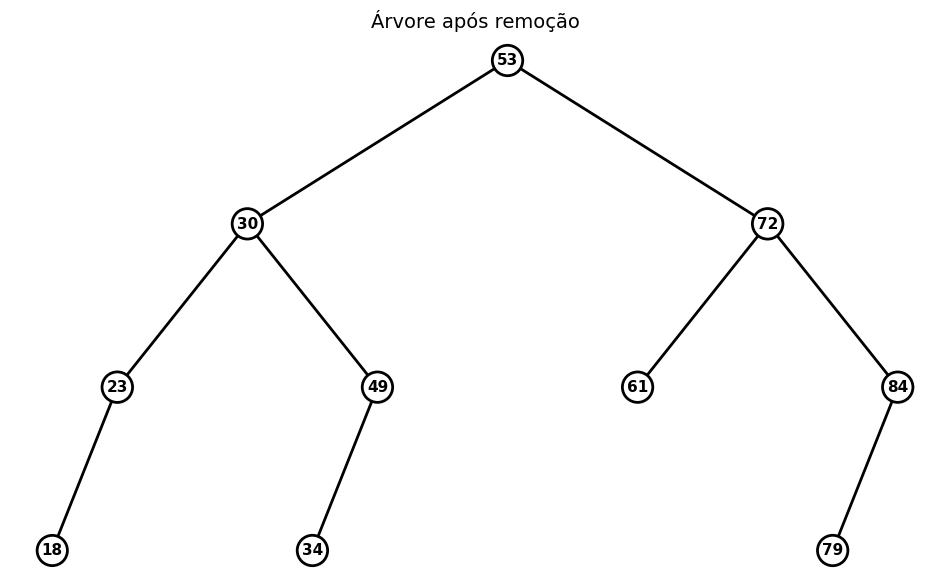

In [57]:
valor_remover = 39
raiz = remover_no(arvore, raiz, valor_remover)
print(f"Valor {valor_remover} removido da árvore.")
desenhar_arvore(
    arvore,
    raiz,
    "Árvore após remoção",
    destacado=valor_remover
)

# Exercício 13 — Busca de Profundidade

In [58]:
# Exercício 13 — Busca de Profundidade
pilha = [raiz]
busca_profundidade = []

while pilha:
    atual = pilha.pop()
    if atual is None:
        continue

    busca_profundidade.append(atual)

    direita = arvore[atual]["direita"]
    esquerda = arvore[atual]["esquerda"]

    if direita is not None:
        pilha.append(direita)
    if esquerda is not None:
        pilha.append(esquerda)

print("Busca de profundidade (DFS)", busca_profundidade)


Busca de profundidade (DFS) [53, 30, 23, 18, 49, 34, 72, 61, 84, 79]


# Exercício 14 — Busca em Largura

In [59]:
# Exercício 14 — Busca em Largura
from collections import deque
fila = deque([raiz])
busca_largura = []

while fila:
    atual = fila.popleft()
    if atual is None:
        continue

    busca_largura.append(atual)

    if arvore[atual]["esquerda"] is not None:
        fila.append(arvore[atual]["esquerda"])
    if arvore[atual]["direita"] is not None:
        fila.append(arvore[atual]["direita"])

print("Busca em largura (BFS):", busca_largura)


Busca em largura (BFS): [53, 30, 72, 23, 49, 61, 84, 18, 34, 79]


# Exercício 15 — Verificação de Existência

In [60]:
# Exercício 15 — Verificação de Existência
def existe_valor(arvore, no, valor):
    atual = no
    while atual is not None:
        if valor == atual:
            return True
        elif valor < atual:
            atual = arvore[atual]["esquerda"]
        else:
            atual = arvore[atual]["direita"]
    return False

valor_procurado = 39
print(f"Valor {valor_procurado} existe na árvore? {existe_valor(arvore, raiz, valor_procurado)}")


Valor 39 existe na árvore? False


# Exercício 16 — Soma dos Valores da Árvore

In [61]:
# Exercício 16 — Soma dos Valores da Árvore
def soma_arvore(arvore, no):
    if no is None:
        return 0
    return no + soma_arvore(arvore, arvore[no]["esquerda"]) + soma_arvore(arvore, arvore[no]["direita"])

print("Soma dos valores da árvore:", soma_arvore(arvore, raiz))


Soma dos valores da árvore: 503


# Exercício 17 — Conversão para Lista Ordenada

In [62]:
# Exercício 17 — Conversão para Lista Ordenada
lista_ordenada = []
def converter_para_lista_ordenada(arvore, no):
    if no is None:
        return
    converter_para_lista_ordenada(arvore, arvore[no]["esquerda"])
    lista_ordenada.append(no)
    converter_para_lista_ordenada(arvore, arvore[no]["direita"])

converter_para_lista_ordenada(arvore, raiz)
print("Lista ordenada da árvore:", lista_ordenada)


Lista ordenada da árvore: [18, 23, 30, 34, 49, 53, 61, 72, 79, 84]


# Exercício 18 — Verificação de Balanceamento

In [63]:
# Exercício 18 — Verificação de Balanceamento
def altura_balanceada(arvore, no):
    if no is None:
        return 0, True

    altura_esq, bal_esq = altura_balanceada(arvore, arvore[no]["esquerda"])
    altura_dir, bal_dir = altura_balanceada(arvore, arvore[no]["direita"])
    altura = 1 + max(altura_esq, altura_dir)
    balanceado = bal_esq and bal_dir and abs(altura_esq - altura_dir) <= 1
    return altura, balanceado

_, balanceada = altura_balanceada(arvore, raiz)
print("Árvore balanceada?", balanceada)


Árvore balanceada? True


# Exercício 19 — Desenho da Árvore

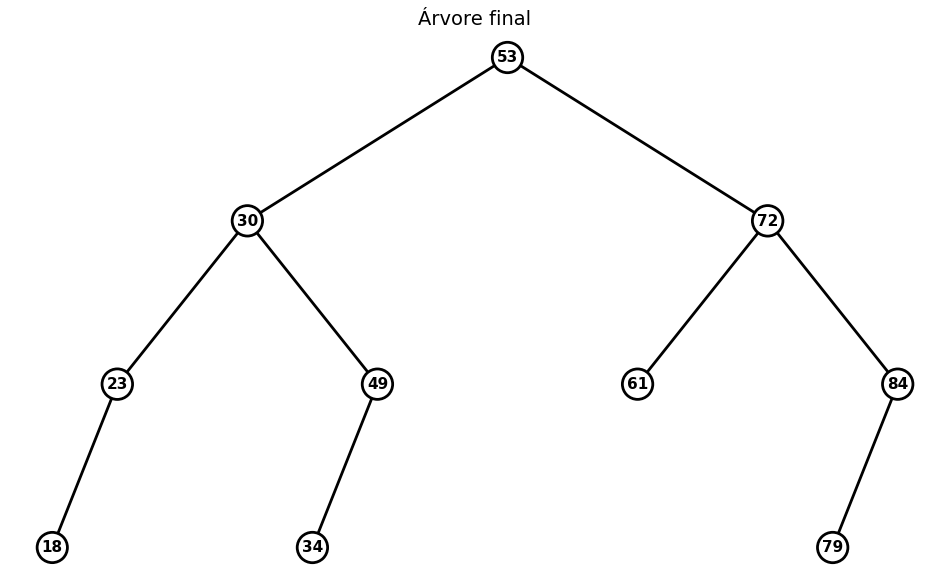

In [64]:
# Exercício 19 — Desenho da Árvore
desenhar_arvore(arvore, raiz, "Árvore final")


# Exercício 20 — Desafio

Exercícios Teóricos
Exercício 21
Explique a diferença entre:
árvore binária
árvore binária de busca
Exercício 22
Explique:
O que é um nó raiz.
O que é um nó folha.
O que é altura.
O que é profundidade.
O que é subárvore.
Exercício 23
Qual é a complexidade média da busca em uma ABB?
Explique:
Melhor caso
Caso médio
Pior caso
Exercício 24
Explique por que árvores degeneradas podem se tornar semelhantes a listas encadeadas.
Dê exemplos.
Desafio Extra
Pesquise e explique:
Árvores AVL
Árvores Rubro-Negras
Diferença entre ABB comum e AVL
Por que árvores balanceadas são importantes

# Árvore Trie

In [ ]:
# Árvore Trie

avore_trie = {}

def adicionar_palavra(arvore, palavra):
    atual = arvore

    for letra in palavra:
        if letra not in atual:
            atual[letra] = {}
        atual = atual[letra]

    atual["*"] = True  # Marca o fim da palavra

def pesquisar_palavra(arvore, palavra):
    atual = arvore

    for letra in palavra:
        if letra not in atual:
            return False
        atual = atual[letra]

    return "*" in atual  # Verifica se é o fim da palavra



In [ ]:
# Exemplo de uso
adicionar_palavra(avore_trie, "feijão")
print("Árvore Trie:", avore_trie)
print("Pesquisar 'casa':", pesquisar_palavra(avore_trie, "casa"))
print("Pesquisar 'casinha':", pesquisar_palavra(avore_trie, "casinha"))
print("Pesquisar 'ontem':", pesquisar_palavra(avore_trie, "ontem"))

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def desenhar_trie_perfeita(trie_dict):
    G = nx.DiGraph()
    G.add_node("root", label="Raiz", color="lightblue")

    # 1. Constrói o Grafo iterando pelos dicionários
    def construir_grafo(sub_trie, id_pai):
        for chave, valor in sub_trie.items():
            if chave == '*':
                G.nodes[id_pai]['color'] = 'lightgreen'
                continue
            
            id_filho = f"{id_pai}_{chave}_{id(valor)}"  # ID único para evitar colisões
            G.add_node(id_filho, label=chave, color="gainsboro")
            G.add_edge(id_pai, id_filho)
            
            if isinstance(valor, dict):
                construir_grafo(valor, id_filho)

    construir_grafo(trie_dict, "root")

    # 2. Algoritmo para posicionar os nós perfeitamente em formato de árvore (Cima para Baixo)
    def _hierarchy_pos(graph, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None):
        if pos is None:
            pos = {root: (xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
            
        children = list(graph.neighbors(root))
        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(graph, child, width=dx, vert_gap=vert_gap, 
                                     vert_loc=vert_loc-vert_gap, xcenter=nextx, pos=pos)
        return pos

    # Calcula as posições perfeitas dos nós
    pos = _hierarchy_pos(G, "root")

    # 3. Renderização do Gráfico com Matplotlib
    labels = nx.get_node_attributes(G, 'label')
    node_colors = [G.nodes[n].get('color', 'gainsboro') for n in G.nodes()]

    # Aumenta o tamanho da figura dinamicamente com base no tamanho da árvore
    largura_figura = max(10, len(G.nodes) // 3)
    plt.figure(figsize=(largura_figura, 8))
    
    # Desenha os nós, linhas e letras
    nx.draw_networkx_nodes(G, pos, node_size=900, node_color=node_colors, edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="gray", width=1.2)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight="bold")

    plt.title("Visualização Hierárquica da Árvore Trie", fontsize=14, fontweight="bold", pad=20)
    plt.axis("off")
    plt.show()

In [ ]:
desenhar_trie_perfeita(avore_trie)

In [ ]:
def separa_palavras_frase(frase):
    palavras = frase.split()
    return palavras

def adicionar_palavras_trie(avore_trie, palavras):
    for palavra in palavras:
        adicionar_palavra(avore_trie, palavra)
    return True

def sugestoes_palavras_trie(avore_trie, prefixo):
    atual = avore_trie
    for letra in prefixo:
        if letra not in atual:
            return []
        atual = atual[letra]

    sugestoes = []

    def coletar_palavras(sub_trie, caminho):
        for chave, valor in sub_trie.items():
            if chave == '*':
                sugestoes.append(caminho)
            elif isinstance(valor, dict):
                coletar_palavras(valor, caminho + chave)

    coletar_palavras(atual, prefixo)
    return sugestoes

In [ ]:
frase = input("Digite uma frase: ")
palavras = separa_palavras_frase(frase)
adicionar_palavras_trie(avore_trie, palavras)

In [ ]:
prefixo = input("Digite as primeiras letras: ")
sugestoes = sugestoes_palavras_trie(avore_trie, prefixo)
print("Sugestões de palavras:", sugestoes)